## Projeto do Bootcamp Avanti - Machine Learning

🔹 Projeto 03

📌 Assunto: Classificação de lesões em folhas de feijão

🔗 Dataset: https://www.kaggle.com/datasets/marquis03/bean-leaf-lesions-classification


### Participantes:
Cristiane Santos da Cunha

Dayna Lilian Figueiredo

Elizabeth Ribeiro de Souza Fagundes

Eric Gabriel Aguiar de Alencar

Fabrício Almeida Santos

Ian Silva Nogueira

Jaime Teixeira de Araújo Júnior

Juliana Gonçalves Câmara

Luis Fernando Mendes da Silva



### ATIVIDADE-04-ETAPA-01
#### Objetivo: Apresentar informações do dataset





#### Baixar dataset do Kaggle

In [2]:
!pip install opendatasets
!pip install pandas
!pip install imagehash

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 6.6 MB/s eta 0:00:00


In [3]:
import opendatasets as od
import pandas as pd

dataset_path = od.download("https://www.kaggle.com/datasets/marquis03/bean-leaf-lesions-classification")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: eng.criscunha@gmail.com
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/marquis03/bean-leaf-lesions-classification


100%|██████████| 155M/155M [00:01<00:00, 126MB/s]


In [4]:
!ls

bean-leaf-lesions-classification  sample_data


### Criar um Dataframe com os metadados das imagens

In [8]:
import cv2
import os

In [12]:
root_dir = './bean-leaf-lesions-classification/train'

In [13]:
import pandas as pd
import imagehash
import matplotlib.pyplot as plt
%matplotlib inline

from PIL import Image
count_corrupted = 0
corrupted = list()

In [14]:
dataframe_list = list()
for folder in os.listdir(root_dir):
  child_dir = os.path.join(root_dir, folder)

  for image in os.listdir(child_dir):
    img_dir = os.path.join(child_dir, image)
    _, image_format = image.rsplit('.', 1)
    image_format = image_format.lower()
    img = cv2.imread(img_dir)


    if img is not None:
      img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
      # Converter a imagem OpenCV para uma imagem do Pillow
      img_pil = Image.fromarray(img_rgb)

      # Gerar o hash da imagem (usando perceptual hash como exemplo)
      img_hash = imagehash.phash(img_pil)
      width, height, channels = img.shape
      img_corrupted = False
    else:
      count_corrupted += 1
      corrupted.append(img_dir)
      img_corrupted = True
      img_hash, image_format, width, height, channels = None, None, None, None, None

    dataframe_list.append([img_dir, img_corrupted, img_hash, image_format, width, height, channels, folder])

### Integridade dos Arquivos

In [15]:
print(f'Total de Imagens Corrompidas: {count_corrupted}\nImagens corrompidas {corrupted}')

Total de Imagens Corrompidas: 1
Imagens corrompidas ['./bean-leaf-lesions-classification/train/healthy/healthy_train.120tore']


In [16]:
import os

if os.path.exists(corrupted[0]):
    os.remove(corrupted[0])
else:
    print(f"O arquivo {corrupted[0]} não foi encontrado. Pode já ter sido removido ou não existe.")

In [17]:
import os

print(os.path.exists(corrupted[0]))

False


In [18]:
# estrutura do data set

import os

print(os.listdir("./bean-leaf-lesions-classification"))

['val', 'val.csv', 'train', 'train.csv', 'classname.txt']


In [19]:
import pandas as pd

train_df = pd.read_csv("./bean-leaf-lesions-classification/train.csv")

train_df.head()

,image:FILE,category
0,train/healthy/healthy_train.98.jpg,0
1,train/healthy/healthy_train.148.jpg,0
2,train/healthy/healthy_train.306.jpg,0
3,train/healthy/healthy_train.305.jpg,0
4,train/healthy/healthy_train.40.jpg,0


In [20]:
print(train_df.columns)

Index(['image:FILE', 'category'], dtype='object')


In [21]:
import pandas as pd
import os

# Ler o CSV
train_df = pd.read_csv("./bean-leaf-lesions-classification/train.csv")

# Imagens listadas no CSV
imagens_csv = set(train_df["image:FILE"])

# Imagens existentes na pasta
imagens_pasta = set()

train_dir = "./bean-leaf-lesions-classification/train"

for classe in os.listdir(train_dir):
    pasta = os.path.join(train_dir, classe)

    if os.path.isdir(pasta):
        for img in os.listdir(pasta):
            imagens_pasta.add(img)

# Comparação
faltando = imagens_csv - imagens_pasta
extras = imagens_pasta - imagens_csv

print(f"Imagens listadas no CSV: {len(imagens_csv)}")
print(f"Imagens encontradas na pasta: {len(imagens_pasta)}")
print(f"Imagens no CSV e ausentes na pasta: {len(faltando)}")
print(f"Imagens na pasta e ausentes no CSV: {len(extras)}")

Imagens listadas no CSV: 1034
Imagens encontradas na pasta: 1034
Imagens no CSV e ausentes na pasta: 1034
Imagens na pasta e ausentes no CSV: 1034


In [22]:
# Validação

val_df = pd.read_csv("./bean-leaf-lesions-classification/val.csv")

imagens_csv = set(val_df["image:FILE"])
imagens_pasta = set()

val_dir = "./bean-leaf-lesions-classification/val"

for classe in os.listdir(val_dir):
    pasta = os.path.join(val_dir, classe)

    if os.path.isdir(pasta):
        for img in os.listdir(pasta):
            imagens_pasta.add(img)

faltando = imagens_csv - imagens_pasta
extras = imagens_pasta - imagens_csv

print(f"Imagens listadas no CSV: {len(imagens_csv)}")
print(f"Imagens encontradas na pasta: {len(imagens_pasta)}")
print(f"Imagens no CSV e ausentes na pasta: {len(faltando)}")
print(f"Imagens na pasta e ausentes no CSV: {len(extras)}")

Imagens listadas no CSV: 133
Imagens encontradas na pasta: 133
Imagens no CSV e ausentes na pasta: 133
Imagens na pasta e ausentes no CSV: 133


#### Verificar se todas as imagens estão no mesmo formato

In [23]:
import os
from collections import Counter

root = "./bean-leaf-lesions-classification"

formatos = []

# Percorre todas as pastas do dataset
for conjunto in ["train", "val"]:
    pasta_conjunto = os.path.join(root, conjunto)

    for classe in os.listdir(pasta_conjunto):
        pasta_classe = os.path.join(pasta_conjunto, classe)

        if not os.path.isdir(pasta_classe):
            continue

        for arquivo in os.listdir(pasta_classe):
            extensao = os.path.splitext(arquivo)[1].lower()
            formatos.append(extensao)

# Conta quantos arquivos existem de cada formato
contagem = Counter(formatos)

print("Formatos encontrados:")
for formato, quantidade in contagem.items():
    print(f"{formato}: {quantidade} imagens")

Formatos encontrados:
.jpg: 1167 imagens


In [24]:
df = pd.DataFrame(columns=['image_path', 'corrupted', 'image_hash', 'image_format', 'width', 'height', 'channels', 'label'], data = dataframe_list)

In [25]:
df.head()

,image_path,corrupted,image_hash,image_format,width,height,channels,label
0,./bean-leaf-lesions-classification/train/bean_...,False,978268e58e7cc7b0,jpg,500.0,500.0,3.0,bean_rust
1,./bean-leaf-lesions-classification/train/bean_...,False,9fd30de8073d6628,jpg,500.0,500.0,3.0,bean_rust
2,./bean-leaf-lesions-classification/train/bean_...,False,80cf3d2ff0607317,jpg,500.0,500.0,3.0,bean_rust
3,./bean-leaf-lesions-classification/train/bean_...,False,d1c42bc2358b6ecb,jpg,500.0,500.0,3.0,bean_rust
4,./bean-leaf-lesions-classification/train/bean_...,False,c79f63881a471b74,jpg,500.0,500.0,3.0,bean_rust


In [26]:
#Informações estatísticas dos valores de altura, largura e canais das imagens

df.describe().loc[['mean', 'std', 'min', 'max']]

,width,height,channels
mean,500.0,500.0,3.0
std,0.0,0.0,0.0
min,500.0,500.0,3.0
max,500.0,500.0,3.0


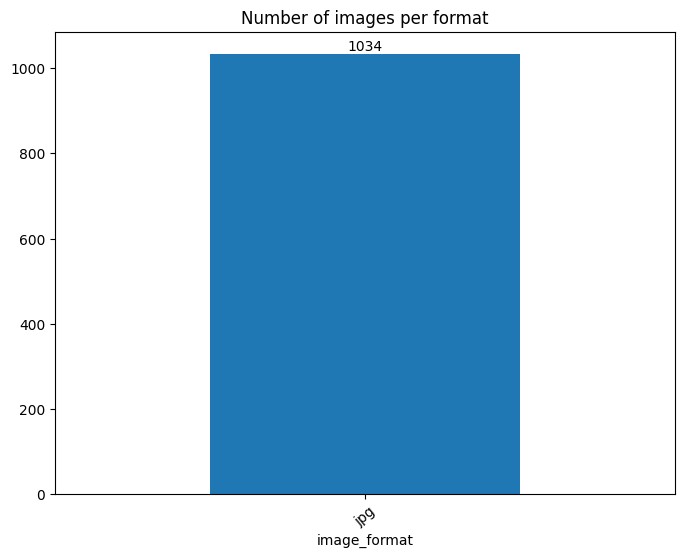

In [27]:
#Quantidade de Imagens por formato (JPG, PNG, etc.)

# Geração do gráfico de barras
ax = df['image_format'].value_counts().plot(kind='bar', title='Number of images per format', figsize=(8, 6))

# Rotacionando os rótulos no eixo X
plt.xticks(rotation=40)

# Adicionando os valores exatos em cima de cada barra
for p in ax.patches:
    ax.annotate(str(int(p.get_height())),
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=10)

# Exibindo o gráfico
plt.show()

##### Resumo:


Foi encontrado o arquivo 'healthy_train.120tore' como corrompido e foi excluído.

Foi avaliada a estrutura do dataset

Foi realizada a avaliação da quantidade de imagens no CSV e nas pastas:

Imagens listadas no CSV: 1034
Imagens encontradas na pasta: 1034
Imagens no CSV e ausentes na pasta: 1034
Imagens na pasta e ausentes no CSV: 1034

Foi realizada a validação das imagens:
Imagens listadas no CSV: 133
Imagens encontradas na pasta: 133
Imagens no CSV e ausentes na pasta: 133
Imagens na pasta e ausentes no CSV: 133

Foi verificado se todas as imagens estão no mesmo formato: .jpg: 1167 imagens e gerado o gráfico


### Consistência dos Metadados

### Qualidade das Imagens

### Distribuição das Classes

### Duplicatas

### Informações complementares
Elaborar uma apresentação para mostrar os resultados.

Apresentar o dataset de forma detalhada.

Verifique quais itens em Informações esperadas podem ser aplicados no dataset.

### ATIVIDADE-04-ETAPA-02

#### Objetivo: Apresentar métodos da literatura e propor ideias para métodos próprios.



### Métodos da literatura

### Métodos próprios

#### Apresentar ideias que podem melhorar os métodos encontrados e testados da literatura.

#### Ideias para melhorar uma técnica

Otimização de Hiperparâmetros - alterar ou reduzir os hiperparâmetros.

Elaborar uma nova arquitetura mais leve para que o treino e o teste sejam rápidos.

Reduzir número de imagens no treinamento e manter o desempenho.

### Informações complementares

Elaborar uma apresentação para mostrar os métodos da literatura e próprios.

### ATIVIDADE-04-ETAPA-03

#### Objetivo

Apresentar métodos da literatura e métodos próprios.

### Metodologia

### Resultados

### Conclusões